PaySim Synthetic Financial Dataset for Fraud Detection


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,confusion_matrix,f1_score,precision_recall_curve,accuracy_score
from sklearn.preprocessing import LabelEncoder

data=pd.read_csv("creditcarddetaction.csv")
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

leb=LabelEncoder()
data["type"]=leb.fit_transform(data["type"])
data["isFraud"]=data["isFraud"].astype("int")
data=data.drop(["nameOrig","nameDest","isFlaggedFraud"],axis=1)

data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1
3,1,1,181.00,181.0,0.00,21182.0,0.0,1
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0


In [ ]:
x=data[["step","type","amount","oldbalanceOrg","newbalanceOrig","newbalanceDest","oldbalanceDest"]]
y=data["isFraud"]
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=42)

model = RandomForestClassifier(
    n_estimators=150,        
    max_depth=20,            
    min_samples_split=8,     
    min_samples_leaf=8,      
    n_jobs=-1,               
    class_weight="balanced", 
    random_state=42
)
model.fit(xtrain, ytrain)
yprobability= model.predict_proba(xtest)[:,1]

ypred=(yprobability>0.6).astype("int")

KeyboardInterrupt: 

In [ ]:
print("precision:",precision_score(ytest,ypred))
print("recall:",recall_score(ytest,ypred))
print("f1_score:",f1_score(ytest,ypred))
print("confusion matrix:\n",confusion_matrix(ytest,ypred))
print("accuracy:",accuracy_score(ytest,ypred))


precision: 0.799124726477024
recall: 0.8929095354523228
f1_score: 0.8434180138568129
confusion matrix:
 [[1588151     459]
 [    219    1826]]
accuracy: 0.9995737604948904


isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64
isFraud
0    6354407
1       8213
Name: count, dtype: int64


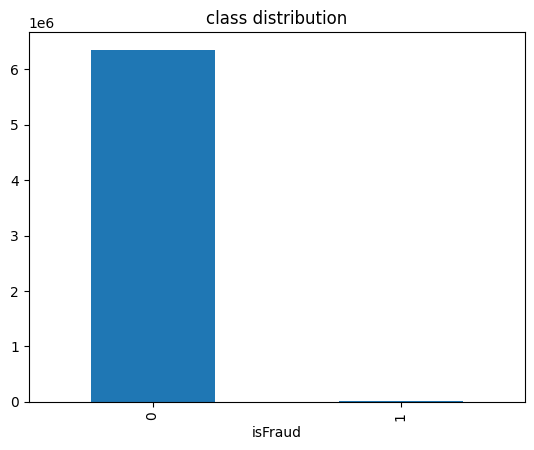

In [ ]:
print(data["isFraud"].value_counts(normalize=True)*100)
print(data["isFraud"].value_counts())

data["isFraud"].value_counts().plot(kind="bar")
plt.title("class distribution")
plt.show()

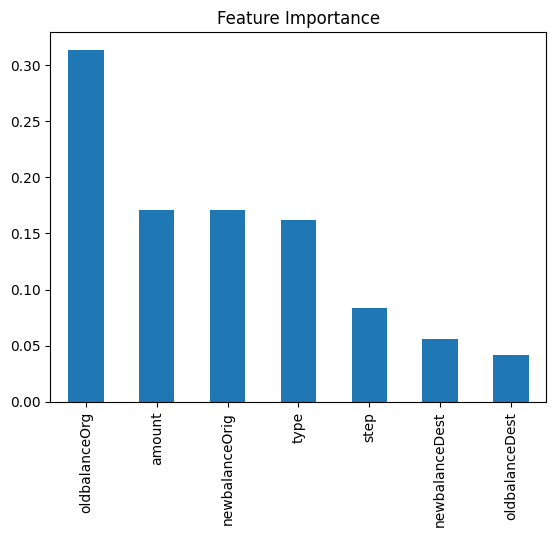

In [ ]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=["step","type","amount","oldbalanceOrg","newbalanceOrig","newbalanceDest","oldbalanceDest"])

feature_importance.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

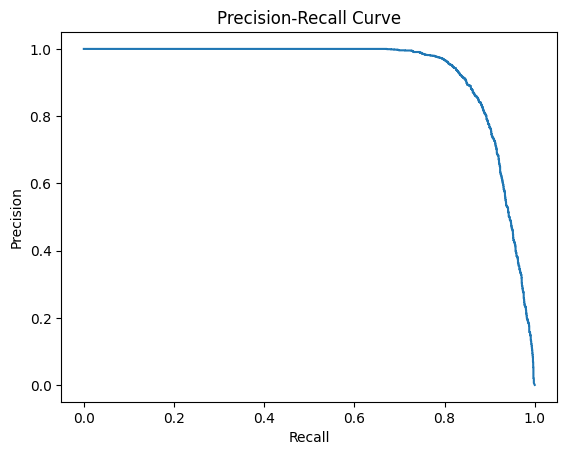

In [ ]:

precision, recall, thresholds = precision_recall_curve(ytest, yprobability)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# Example new transaction
new_data = pd.DataFrame([{
    "step": 5,
    "type": leb.transform(["CASH_OUT"])[0],
    "amount": 1500.50,
    "oldbalanceOrg": 5000,
    "newbalanceOrig": 3500,
    "newbalanceDest":1000,
    "oldbalanceDest":1220
}])
    
# Predict probability
probability= model.predict_proba(new_data)

prediction=(probability>0.6).astype("int").all()

if prediction==1:
    print("Fraud Transaction")
else:
    print("Not a Fraud Transaction")


Not a Fraud Transaction


In [ ]:
import joblib
filename="model.pkl"
joblib.dump(model,filename)
joblib.dump(leb,"label_encoder.pkl")
print("file saved successfully as ",filename)
print("label encoder saved successfully as label_encoder.pkl")

file saved successfully as  model.pkl
label encoder saved successfully as label_encoder.pkl
